<a href="https://colab.research.google.com/github/javierraneros-cell/UD2-Mineria-de-Datos---Colab-/blob/main/Practica_UD2_ATLETAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
Este es un ejemplo de un comentario
que abarca varias líneas en Python.
Todo lo que esté dentro de estas comillas
será ignorado por el intérprete.
'''

# También puedes usar comillas dobles triples:
"""
Este es otro ejemplo de comentario multilínea.
Es útil para explicaciones más largas
o para desactivar temporalmente bloques de código.
"""

def mi_funcion():
    """Este es un docstring, una forma especial de comentario multilínea
    que describe la función. Se puede acceder a él a través de help(mi_funcion).
    """
    print("Hola desde mi función!")

mi_funcion()

## INTRODUCCIÓN

En esta actividad se va a trabajar con conjunto de datos que contiene las marcas de los alumnos de un centro de alto rendimiento en diferentes pruebas atléticas. Concretamente, los campos que se recogen son los siguientes:

grupo clase a la que pertenece cada alumno (A o B)

*   100m lisos: marca en la prueba de 100 metros lisos
*   400m lisos: marca en la prueba de 400 metros lisos
*   100m vallas: marca en la prueba de 100 metros vallas
*   1500m lisos: marca en la prueba de 1500 metros lisos
*   salto horizontal: marca en el salto de longitud
*   lanzamiento de peso: marca en lanzamiento de peso o de bala (bola de acero)
*   salto de altura: marca en el salto vertical de altura
*   disco: marca en lanzamiento de disco
*   pértiga: marca en salto con pértiga
*   jabalina: marca en lanzamiento de jabalina

El objetivo final es calcular una única medida que permita determinar el rendimiento de cada alumno. Como se tratan de diferentes pruebas medidas en diferentes unidades, resulta complicado encontrar la forma de resumir los resultados en un único valor numérico. Para esta tarea se va a utilizar el análisis de componentes principales que permite reducir el número de dimensiones manteniendo la mayor cantidad de información posible. Concretamente, se desea reducir el número de dimensiones a 1.


# PREPARACIÓN DE LOS DATOS

## Importacion de ficheros CSV

Para esta tarea se facilitan 4 ficheros separadaos para cada atleta en las diferentes marcas descritas anteriormente y 2 días, por lo cual habrá que unir o concatenar los ficheros en un único Dataset.

Los 4 ficheros CSV se encuentran en el Drive al mismo nivel que el cuaderno Colab Notebook, por lo que se procede a su carga en la carpeta csv del proyecto:

In [1]:
# Instalar gdown si no está instalado
!pip install gdown

Para incorporar el fichero de Google Drive al proyecto hay que descargarlo con **gdown** y guaradarlos como ficheros CSV para despues ser usados en la creación del/los Datasets:

*   grupoA_primer_dia.csv 	--> 17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
*   grupoA_segundo_dia.csv 	--> 1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
*   grupoB_primer_dia.csv		--> 1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
*   grupoB_segundo_dia.csv	--> 1jvkkCQLWtOoHM3Pe2p0zwleyWeXLnpYG

In [2]:
import gdown

#IDs de los archivos a descargar de Google Drive que tienen que estar compartidos
# grupoA_primer_dia.csv 	--> 17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
# grupoA_segundo_dia.csv 	--> 1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
# grupoB_primer_dia.csv		--> 1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
# grupoB_segundo_dia.csv	--> 1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv

file_grupoA_primer_dia_id = '17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0'
file_grupoA_segundo_dia_dia_id = '1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU'
file_grupoB_primer_dia_id = '1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd'
file_grupoB_segundo_dia_id = '1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv'

output_grupoA_primer_dia = 'grupoA_primer_dia.csv'
output_grupoA_segundo_dia = 'grupoA_segundo_dia.csv'
output_grupoB_primer_dia = 'grupoB_primer_dia.csv'
output_grupoB_segundo_dia = 'grupoB_segundo_dia.csv'

#GRUPO A
#Primer dia
url = f'https://drive.google.com/uc?id={file_grupoA_primer_dia_id}'
gdown.download(url, output_grupoA_primer_dia, quiet=False)
print('\nPrimer dia GRUPO A descargado...')
#Segundo dia
url = f'https://drive.google.com/uc?id={file_grupoA_segundo_dia_dia_id}'
gdown.download(url, output_grupoA_segundo_dia, quiet=False)
print('\nSegundo dia GRUPO A descargado...')
#GRUPO B
#Primer dia
url = f'https://drive.google.com/uc?id={file_grupoB_primer_dia_id}'
gdown.download(url, output_grupoB_primer_dia, quiet=False)
print('\nPrimer dia GRUPO B descargado...')
#Segundo dia
url = f'https://drive.google.com/uc?id={file_grupoB_segundo_dia_id}'
gdown.download(url, output_grupoB_segundo_dia, quiet=False)
print('\nSegundo dia GRUPO B descargado...')


Downloading...
From: https://drive.google.com/uc?id=17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
To: /content/grupoA_primer_dia.csv
100%|██████████| 496/496 [00:00<00:00, 1.34MB/s]



Primer dia GRUPO A descargado...


Downloading...
From: https://drive.google.com/uc?id=1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
To: /content/grupoA_segundo_dia.csv
100%|██████████| 633/633 [00:00<00:00, 1.80MB/s]



Segundo dia GRUPO A descargado...


Downloading...
From: https://drive.google.com/uc?id=1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
To: /content/grupoB_primer_dia.csv
100%|██████████| 1.02k/1.02k [00:00<00:00, 3.53MB/s]



Primer dia GRUPO B descargado...


Downloading...
From: https://drive.google.com/uc?id=1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv
To: /content/grupoB_segundo_dia.csv
100%|██████████| 1.24k/1.24k [00:00<00:00, 3.03MB/s]


Segundo dia GRUPO B descargado...


## Creación Datasets

Tenemos que unir los 4 ficheros en una única fuente de datos. Para ello lo que vamos a hacer es crear 4 Datasets por cada ficheros csv y despues los concatenaremos.



In [3]:
import pandas as pd

#Creación de 4 Datasets y mostramos los datos
df_grupoA_primer_dia = pd.read_csv(output_grupoA_primer_dia)
print(f"Archivo '{output_grupoA_primer_dia}' descargado y cargado exitosamente.")
display(df_grupoA_primer_dia.head())

df_grupoA_segundo_dia = pd.read_csv(output_grupoA_segundo_dia)
print(f"\nArchivo '{output_grupoA_segundo_dia}' descargado y cargado exitosamente.")
display(df_grupoA_segundo_dia.head())

df_grupoB_primer_dia = pd.read_csv(output_grupoB_primer_dia)
print(f"\nArchivo '{output_grupoB_primer_dia}' descargado y cargado exitosamente.")
display(df_grupoB_primer_dia.head())

df_grupoB_segundo_dia = pd.read_csv(output_grupoB_segundo_dia)
print(f"\nArchivo '{output_grupoB_segundo_dia}' descargado y cargado exitosamente.")
display(df_grupoB_segundo_dia.head())




Archivo 'grupoA_primer_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Torres,A,11.04,49.81,14.69,291.7
1,Delgado,A,10.76,49.37,14.05,301.5
2,Ramírez,A,11.02,48.37,14.09,300.2
3,Díaz,A,11.02,48.93,-14.99,280.1
4,Sánchez,A,11.34,50.42,15.31,276.4



Archivo 'grupoA_segundo_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN



Archivo 'grupoB_primer_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Silva,B,10.85,48.36,14.05,280.01
1,González,B,10.44,49.19,14.13,282.00
2,Herrera,B,10.50,46.81,13.97,278.11
3,Guzmán,B,10.89,48.97,14.56,265.42
4,Ríos,B,10.62,47.97,14.01,NaN



Archivo 'grupoB_segundo_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Silva,B,7.84,16.36,2.12,48.72,5.0,70.52
1,González,B,7.96,15.23,2.06,50.11,4.9,69.71
2,Herrera,B,7.81,15.93,2.09,51.65,4.6,55.54
3,Guzmán,B,7.47,15.73,2.15,48.34,4.4,58.46
4,Ríos,B,7.74,14.48,1.97,43.73,4.9,55.39


## CONCATENACION - Integración de los datos

La integración de los 4 Datasets se realizara con la concatenación se realizaría primero uniendo a los grupos A y B de cada dia con una concatenación por FILAS y despues concatenaremos por COLUMNAS para unir todos los registros del primer dia con todos los registros del segundo dia:


> **Concatenacion x FILAS**:
>
>     grupoA_primer_dia + grupoB_primer_dia   --> primer_dia
>
>     grupoA_segundo_dia + grupoB_segundo_dia --> segundo_dia

Para concatenar se usa el método **concat** de Pandas **axis=0** para concatenar por filas y **axis=1** para unir por columnas
```
# concat([dataset1, dataset2], axis= 0 )
```

> **Concatenacion x COLUMNAS**:
>
>     primer_dia +  segundo_dia

```
# concat([dataset1, dataset2], axis= 1 )
```






In [4]:
#Concatenación x FILAS - Dataset primer dia y Segundo dia
df_result_primer_dia = pd.concat([df_grupoA_primer_dia, df_grupoB_primer_dia], axis=0, ignore_index=True)
print(f"\nConcatenacion creada correctamente para df_result_primer_dia ...\n")
display(df_result_primer_dia.head())
display(df_result_primer_dia.tail())

df_result_segundo_dia = pd.concat([df_grupoA_segundo_dia, df_grupoB_segundo_dia], axis=0, ignore_index=True)
print(f"\nConcatenacion creada correctamente para df_result_segundo_dia ...\n")
display(df_result_segundo_dia.head())
display(df_result_segundo_dia.tail())


Concatenacion creada correctamente para df_result_primer_dia ...



,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Torres,A,11.04,49.81,14.69,291.7
1,Delgado,A,10.76,49.37,14.05,301.5
2,Ramírez,A,11.02,48.37,14.09,300.2
3,Díaz,A,11.02,48.93,-14.99,280.1
4,Sánchez,A,11.34,50.42,15.31,276.4


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
36,Figueroa,B,11.10,49.34,15.38,263.08
37,Aguilar,B,11.33,50.54,14.98,278.67
38,Montes,B,10.86,51.16,14.96,317.00
39,Morales,B,11.23,50.95,15.09,281.70
40,Jiménez,B,11.36,53.20,15.39,296.12



Concatenacion creada correctamente para df_result_segundo_dia ...



,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,6.68,14.92,1.94,48.66,4.4,58.62


In [5]:
#Concatenacion x COLUMNAS
df_dataset = pd.concat([df_result_primer_dia, df_result_segundo_dia], axis=1)
print(f"\nConcatenacion creada correctamente para df_dataset ...\n")
display(df_dataset.head())
display(df_dataset.tail())


Concatenacion creada correctamente para df_dataset ...



,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.1,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,Figueroa,B,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,Aguilar,B,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,Montes,B,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,Morales,B,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,Jiménez,B,6.68,14.92,1.94,48.66,4.4,58.62


In [6]:
# Antes de eliminar, comprobamos que las posiciones 6 y 7 son de columnas duplicadas tras hacer la concatenación
print("Nombres de las columnas antes de eliminar:")
print(df_dataset.columns.tolist())

# Explicación del problema: df.drop() elimina todas las columnas con el nombre especificado.
# Para eliminar SOLO las columnas en las posiciones 6 y 7, seleccionaremos explícitamente las columnas que queremos mantener.

# Creamos una lista de índices de columnas que queremos mantener:
# Queremos mantener las columnas desde el índice 0 hasta el 5 (inclusive)
# y las columnas desde el índice 8 hasta el final.
columns_to_keep_indices = list(range(6)) + list(range(8, len(df_dataset.columns)))

# Seleccionar estas columnas para crear el nuevo DataFrame limpio,
# seleccionando con ILOC porque por nombre no podríamos referenciarlas al estar duplicadas:

df_dataset = df_dataset.iloc[:, columns_to_keep_indices]

print("\nDataFrame después de eliminar las columnas duplicadas por índice:")
display(df_dataset.head())
display(df_dataset.tail())
print(f"El DataFrame ahora tiene {df_dataset.shape[1]} columnas.")
print("Nombres de las columnas después de eliminar:")
print(df_dataset.columns.tolist())

Nombres de las columnas antes de eliminar:
['alumno', 'grupo', '100m lisos', '400m lisos', '100m vallas', '1500m lisos', 'alumno', 'grupo', 'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina']

DataFrame después de eliminar las columnas duplicadas por índice:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.1,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,6.68,14.92,1.94,48.66,4.4,58.62


El DataFrame ahora tiene 12 columnas.
Nombres de las columnas después de eliminar:
['alumno', 'grupo', '100m lisos', '400m lisos', '100m vallas', '1500m lisos', 'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina']


Consultamos los datos en formato tabla para comprobar los datos finales cargados y hacer un análisis visual de los datos con los filtros que podemos disponer, como es el caso de los nulo y los negativos como se indica en la tarea en el punto 2

In [7]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

print("Mostrando el DataFrame df_dataset como una tabla interactiva:")
df_dataset

Mostrando el DataFrame df_dataset como una tabla interactiva:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.70,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.50,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.20,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.10,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.40,7.09,15.19,2.10,46.26,4.72,NaN
5,Miranda,A,11.11,48.68,14.23,278.10,7.60,14.31,1.98,41.10,4.92,51.77
6,Rodríguez,A,11.13,48.62,14.17,268.00,7.30,13.48,2.01,45.67,4.42,55.37
7,Vargas,A,10.83,49.91,14.38,285.10,7.31,13.76,2.13,44.41,4.42,-56.37
8,Castro,A,11.64,50.14,14.93,262.10,6.81,14.57,1.95,47.60,4.92,52.33
9,Pérez,A,11.37,51.10,15.06,285.10,7.56,14.41,1.86,44.99,4.82,57.19


## FILTRAR VALORES NEGATIVOS

Despues de hacer el analisis visual, vemos que hay valores negativos en 100m lisos, 400m lisos, 100m vallas, lanzamiento de peso, salto de altura, pertiga y jabalina, pero vamos a identificar exactamente las columnas numéricas que representan marcas atléticas y las cambiaremos a valor positivo porque es un error de carga.

In [8]:
import numpy as np

# Identificar las columnas numéricas relevantes para filtrar valores negativos
# Excluyendo 'alumno' y 'grupo' que son identificadores o categóricas
performance_columns = [
    '100m lisos', '400m lisos', '100m vallas', '1500m lisos',
    'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina'
]

# Crear una máscara booleana para identificar filas con al menos un valor negativo
# en las columnas de rendimiento. Usamos '.any(axis=1)' para verificar si hay CUALQUIER negativo en la fila.
negative_values_mask = (df_dataset[performance_columns] < 0).any(axis=1)

# Mostrar el número de filas con valores negativos antes de la eliminación
print(f"Número de filas con valores negativos en las columnas de rendimiento antes de filtrar: {negative_values_mask.sum()}")

listaColumnasNegativas = []

# Mostrar las columnas que contienen valores negativos y cargarlo en una lista
print("Columnas con valores negativos detectados:")
for col in performance_columns:
    if (df_dataset[col] < 0).any():
        listaColumnasNegativas.append(col)
        print(f"- {col}")

# Filtrar el DataFrame, manteniendo solo las filas que tienen valores negativos para mostralos en pantalla
df_dataset_negativos = df_dataset[negative_values_mask].copy()

# Mostrar el número de filas después de filtrar y las primeras filas del DataFrame limpio
print(f"\nNúmero de filas después de filtrar valores NEGATIVOS: {len(df_dataset_negativos)}")
print("\nDataFrame con valores negativos:")
display(df_dataset_negativos.head(len(df_dataset_negativos)))

Número de filas con valores negativos en las columnas de rendimiento antes de filtrar: 7
Columnas con valores negativos detectados:
- 100m lisos
- 400m lisos
- 100m vallas
- lanzamiento de peso
- salto de altura
- pértiga
- jabalina

Número de filas después de filtrar valores NEGATIVOS: 7

DataFrame con valores negativos:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
3,Díaz,A,11.02,48.93,-14.99,280.10,7.23,14.25,1.92,40.87,5.32,62.77
7,Vargas,A,10.83,49.91,14.38,285.10,7.31,13.76,2.13,44.41,4.42,-56.37
11,Pacheco,A,11.33,49.20,15.29,266.60,7.27,-12.68,1.98,37.92,4.62,57.44
12,Moreno,A,11.36,51.16,15.67,291.70,6.80,13.46,-1.86,40.49,5.02,54.68
18,Gómez,B,10.91,-49.40,14.95,269.54,7.14,15.31,2.12,45.62,4.70,63.45
28,García,B,-10.68,49.12,15.01,275.71,7.50,14.97,1.94,40.35,4.60,59.26
32,Ramírez,B,11.14,51.04,14.88,277.94,6.61,15.69,2.03,41.90,-4.80,65.82


### Corrección de valores negativos

Vamos a aplicar el valor absoluto a todas las columnas de rendimiento identificadas para convertir los valores negativos en positivos, ya que representan errores en la medición y no tienen sentido físico.

In [9]:
# Aplicar np.abs() a las columnas de rendimiento para convertir los valores negativos a positivos
for registroNegativo in df_dataset_negativos.index:
    for col in performance_columns:
        df_dataset.at[registroNegativo, col] = np.abs(df_dataset.at[registroNegativo, col])

print("Valores negativos en las columnas de rendimiento convertidos a positivos.")
print("\nDataFrame después de corregir valores negativos:")
display(df_dataset.head())
display(df_dataset.tail())

# Verificar si aún existen valores negativos en las columnas de rendimiento después de la corrección
negative_values_after_correction = (df_dataset[performance_columns] < 0).any(axis=1)
if negative_values_after_correction.sum() == 0:
    print("\n¡Verificación completada! No se encontraron valores negativos en las columnas de rendimiento después de la corrección.")
else:
    print(f"\nAdvertencia: Aún se encontraron {negative_values_after_correction.sum()} filas con valores negativos después de la corrección.")
    display(df_dataset[negative_values_after_correction])

Valores negativos en las columnas de rendimiento convertidos a positivos.

DataFrame después de corregir valores negativos:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,14.99,280.1,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,6.68,14.92,1.94,48.66,4.4,58.62



¡Verificación completada! No se encontraron valores negativos en las columnas de rendimiento después de la corrección.


## FILTRAR VALORES NULOS

También se observa que hay ciertos datos nulos. Para comprobar que existen valores nulos, en el dataset que mantenemos, se puede consultar con un simple info() que nos dira el numero de registros cuya columna tiene no nulos, entonces si la cifra es menor que el numero de entradas totales, significa que sí tiene datos nulos o perdidos.

Otra forma es mediante el uso de isnull().sum() que nos dará el total de registros nulos en la muestra poblacional:
```
df.isnull().sum()
```



In [10]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   alumno               41 non-null     object 
 1   grupo                41 non-null     object 
 2   100m lisos           41 non-null     float64
 3   400m lisos           41 non-null     float64
 4   100m vallas          41 non-null     float64
 5   1500m lisos          40 non-null     float64
 6   salto horizontal     41 non-null     float64
 7   lanzamiento de peso  40 non-null     float64
 8   salto de altura      41 non-null     float64
 9   disco                40 non-null     float64
 10  pértiga              40 non-null     float64
 11  jabalina             40 non-null     float64
dtypes: float64(10), object(2)
memory usage: 4.0+ KB


In [11]:
columnas_con_nulos = df_dataset.columns[df_dataset.isnull().sum() != 0]
columnas_con_nulos


Index(['1500m lisos', 'lanzamiento de peso', 'disco', 'pértiga', 'jabalina'], dtype='object')

### Corrección de valores NULOS

Vamos a calcular el valor para las columnas de rendimiento cuyo valor sea perdido o NULO identificadas que son las columnas:

['1500m lisos', 'lanzamiento de peso', 'disco', 'pértiga', 'jabalina']

Se pide en la práctica es que en lugar de eliminar o filtrar los registos, hay que analizar columna por columna para decidir el cálculo de la tendencia central de cada valor y aplicar el valor según proceda por deporte y grupo de alumnos.

> Medidas de tendencia central a calcular para valores perdidos: **MEDIA**, **MEDIANA** o **MODA**


### Calculo TENDENCIAS CENTRALES para corrección de NULOS

Vamos a calcular para cada caso si la población es simétrica o no para emplear los valores de MEDIA o MEDIANA, ya que la Moda en este caso no creemos que pueda ser usada, ya que todos son valores registrados de marcas atléticas.

Analizamos las tendencia con un histograma de frecuencias y para cada caso mostramos también el valor de skewness o la asimetría de la distribución para decidir también en base a ese valor la simetría o asimetría.

* Skewness Cercano a 0 = simetría --> MEDIA
* Skewness < 0 = asimetría negativa  --> MEDIANA
* Skewness > 0 = asimetría positiva  --> MEDIANA

Como especial la tendencia central hay que calcularla agrupando por GRUPO de actividad que es el A y el B. Esto lo hacemos con `HUE` en el filtrado del histograma y con `GROUP BY` en el calculo de distribución o skewness  


Asimetrias obtenidas para 1500m lisos groupby 'grupo' valores: grupo
A   -0.014449
B    1.656693
Name: 1500m lisos, dtype: float64


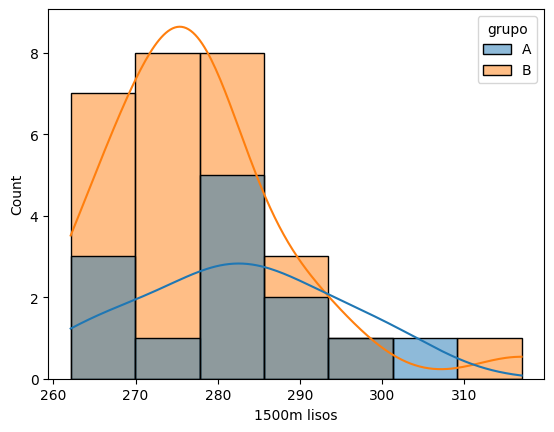

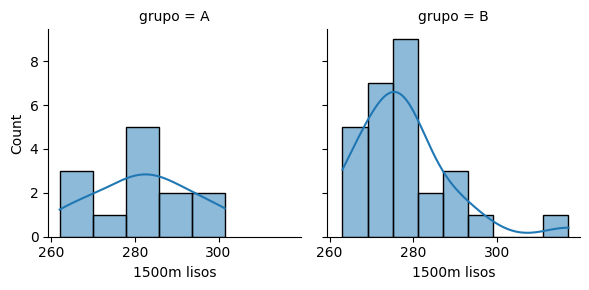


Asimetrias obtenidas para lanzamiento de peso groupby 'grupo' valores: grupo
A   -0.714863
B   -0.180805
Name: lanzamiento de peso, dtype: float64


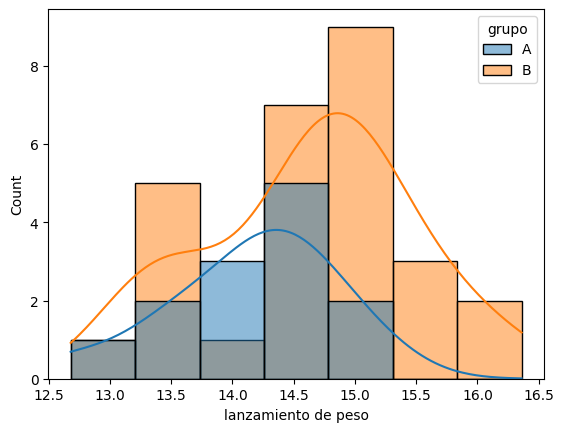

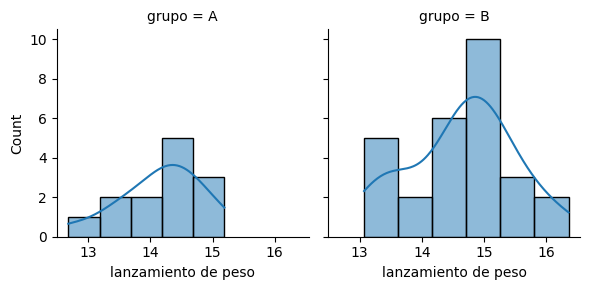


Asimetrias obtenidas para disco groupby 'grupo' valores: grupo
A    0.104323
B    0.426863
Name: disco, dtype: float64


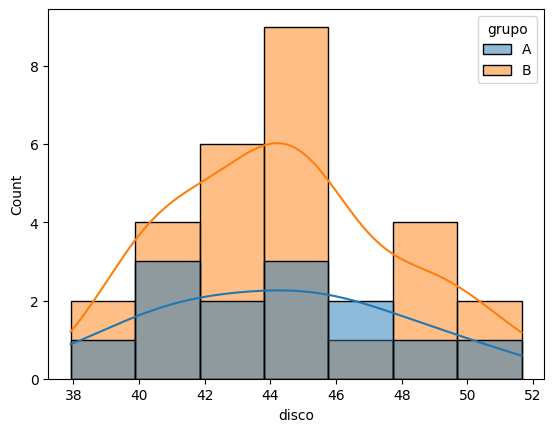

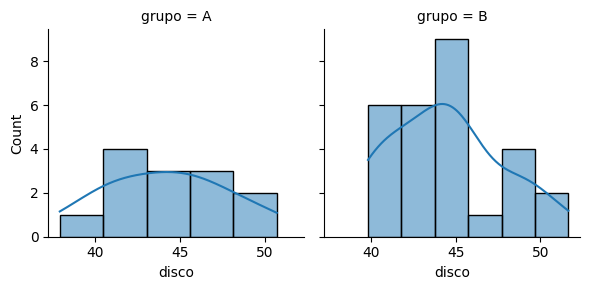


Asimetrias obtenidas para pértiga groupby 'grupo' valores: grupo
A   -0.064995
B    0.522111
Name: pértiga, dtype: float64


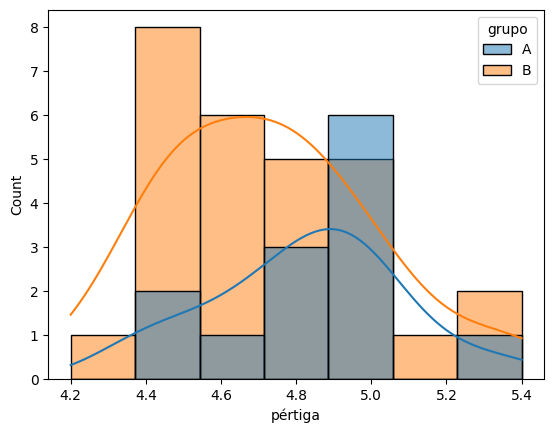

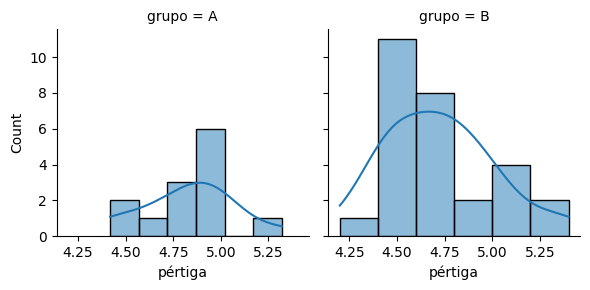


Asimetrias obtenidas para jabalina groupby 'grupo' valores: grupo
A    0.248067
B    0.526326
Name: jabalina, dtype: float64


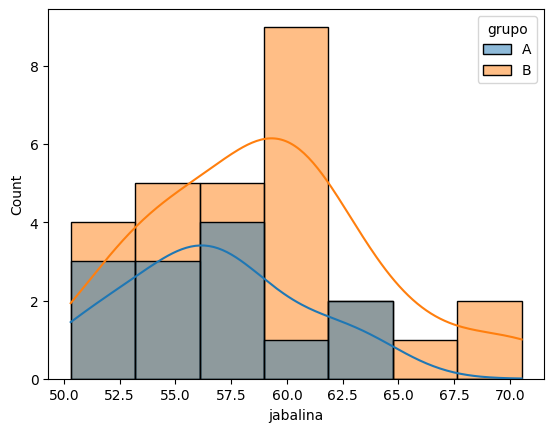

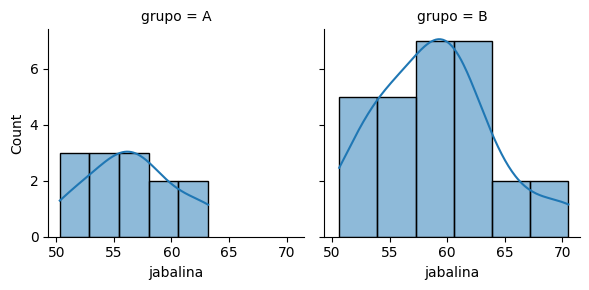

In [14]:
#Usamos la libreria SEABORN y MATPLOTLIB.PYPLOT
import matplotlib.pyplot as plt
import seaborn as sns

# Lo hacemos con todas las columnas recuperadas en columnas_con_nulos
# y como rango BINS en AUTO, para determinar en cuántos rangos se divide
# el histograma agrupando por GRUPO de actividad, que son
for col in columnas_con_nulos:
    sns.histplot(data = df_dataset, x = col, hue='grupo', bins = 'auto', kde = True)
    sns.FacetGrid(df_dataset, col='grupo').map(sns.histplot, col, bins='auto', kde=True)
    skew = df_dataset.groupby('grupo')[col].skew()
    print(f"\nAsimetrias obtenidas para {col} groupby 'grupo' valores: {skew}")
    plt.show()



Con los valores y los histogramas que han resultado podemos determinar que:

GRUPO A:
* 1500m lisos: SIMETRIA -> MEDIA
* lanzamiento de peso: ASIMETRIA negativa -> MEDIANA
* disco: SIMETRIA -> MEDIA
* pértiga: SIMETRIA -> MEDIA
* jabalina: SIMETRIA -> MEDIA

GRUPO B:
* 1500m lisos: ASIMETRIA Positiva -> MEDIANA
* lanzamiento de peso: SIMETRIA -> MEDIA
* disco: SIMETRIA -> MEDIA
* pértiga: LIGERA ASIMETRIA POSITIVA -> MEDIANA
* jabalina: LIGERA ASIMETRIA POSITIVA -> MEDIANA

Con lo que ya podemos ejecutar las siguientes actualizaciones sobre los datos nulos de cada columna, pero vamos a hacerlo con una función que decida segun el valor de skewness:






In [16]:

#Funcion que rellenara de forma automatica los valores no nulos
def f_rellenar_nulos(col, grupo):
    # Calcular skewness, media y mediana por grupo
    skew = df_dataset.groupby('grupo')[col].skew()
    media = df_dataset.groupby('grupo')[col].mean()
    mediana = df_dataset.groupby('grupo')[col].median()

    # Decidir si usar media o mediana
    if abs(skew[grupo]) < 0.5:
        valor = media[grupo]
        print(f"{col} | Grupo {grupo}: skew={skew[grupo]:.3f} → imputando con MEDIA ({valor:.3f})")
    else:
        valor = mediana[grupo]
        print(f"{col} | Grupo {grupo}: skew={skew[grupo]:.3f} → imputando con MEDIANA ({valor:.3f})")

    # Imputar SOLO los nulos del grupo usando fillna()
    df_dataset.loc[ (df_dataset['grupo'] == grupo), col] = df_dataset.loc[df_dataset['grupo'] == grupo, col].fillna(valor)

for col in columnas_con_nulos:
    f_rellenar_nulos(col, 'A')
    f_rellenar_nulos(col, 'B')

#Esto es lo que tenia sin agrupar y a mano sin funcion
'''
# 1500m lisos - MEDIANA
mediana_1500 = df_dataset.loc[:,'1500m lisos'].median()
df_dataset['1500m lisos'] = df_dataset['1500m lisos'].fillna(mediana_1500)
print(f"La MEDIANA de 1500m lisos es: {mediana_1500}")
print(df_dataset['1500m lisos'].isnull().sum())

# lanzamiento de peso: SIMETRIA -> MEDIA
media_lanzamiento_peso = df_dataset.loc[:,'lanzamiento de peso'].mean()
df_dataset['lanzamiento de peso'] = df_dataset['lanzamiento de peso'].fillna(media_lanzamiento_peso)
print(f"La MEDIA de lanzamiento de peso es: {media_lanzamiento_peso}")
print(df_dataset['lanzamiento de peso'].isnull().sum())

# disco: SIMETRIA -> MEDIA
media_disco = df_dataset.loc[:,'disco'].mean()
df_dataset['disco'] = df_dataset['disco'].fillna(media_disco)
print(f"La MEDIA de disco es: {media_disco}")
print(df_dataset['disco'].isnull().sum())

# pértiga: SIMETRIA -> MEDIA
media_pertiga = df_dataset.loc[:,'pértiga'].mean()
df_dataset['pértiga'] = df_dataset['pértiga'].fillna(media_pertiga)
print(f"La MEDIA de pértiga es: {media_pertiga}")
print(df_dataset['pértiga'].isnull().sum())

# jabalina: Ligera ASIMETRIA Positiva -> MEDIANA
mediana_jabalina = df_dataset.loc[:,'jabalina'].median()
df_dataset['jabalina'] = df_dataset['jabalina'].fillna(mediana_jabalina)
print(f"La MEDIANA de jabalina es: {mediana_jabalina}")
print(df_dataset['jabalina'].isnull().sum())
'''


1500m lisos | Grupo A: skew=-0.014 → imputando con MEDIA (282.200)
1500m lisos | Grupo B: skew=1.657 → imputando con MEDIANA (276.320)
lanzamiento de peso | Grupo A: skew=-0.715 → imputando con MEDIANA (14.260)
lanzamiento de peso | Grupo B: skew=-0.181 → imputando con MEDIA (14.642)
disco | Grupo A: skew=0.104 → imputando con MEDIA (44.218)
disco | Grupo B: skew=0.427 → imputando con MEDIA (44.424)
pértiga | Grupo A: skew=-0.065 → imputando con MEDIA (4.828)
pértiga | Grupo B: skew=0.522 → imputando con MEDIANA (4.700)
jabalina | Grupo A: skew=0.248 → imputando con MEDIA (56.541)
jabalina | Grupo B: skew=0.526 → imputando con MEDIANA (58.940)


'\n# 1500m lisos - MEDIANA\nmediana_1500 = df_dataset.loc[:,\'1500m lisos\'].median()\ndf_dataset[\'1500m lisos\'] = df_dataset[\'1500m lisos\'].fillna(mediana_1500)\nprint(f"La MEDIANA de 1500m lisos es: {mediana_1500}")\nprint(df_dataset[\'1500m lisos\'].isnull().sum())\n\n# lanzamiento de peso: SIMETRIA -> MEDIA\nmedia_lanzamiento_peso = df_dataset.loc[:,\'lanzamiento de peso\'].mean()\ndf_dataset[\'lanzamiento de peso\'] = df_dataset[\'lanzamiento de peso\'].fillna(media_lanzamiento_peso)\nprint(f"La MEDIA de lanzamiento de peso es: {media_lanzamiento_peso}")\nprint(df_dataset[\'lanzamiento de peso\'].isnull().sum())\n\n# disco: SIMETRIA -> MEDIA\nmedia_disco = df_dataset.loc[:,\'disco\'].mean()\ndf_dataset[\'disco\'] = df_dataset[\'disco\'].fillna(media_disco)\nprint(f"La MEDIA de disco es: {media_disco}")\nprint(df_dataset[\'disco\'].isnull().sum())\n\n# pértiga: SIMETRIA -> MEDIA\nmedia_pertiga = df_dataset.loc[:,\'pértiga\'].mean()\ndf_dataset[\'pértiga\'] = df_dataset[\'pértig

Y pintamos la tabla con todos los valores en formato tabla de nuevo como parte final del ** EJERCICIO 1** pero con los valores perdidos calculados y los negativos en positivo con su valor absoluto:

In [17]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

print("Mostrando el DataFrame df_dataset como una tabla interactiva:")
df_dataset

Mostrando el DataFrame df_dataset como una tabla interactiva:


,alumno,grupo,100m lisos,400m lisos,100m vallas,...,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,...,14.83000,2.07,43.7500,5.0200,63.19
1,Delgado,A,10.76,49.37,14.05,...,14.26000,1.86,50.7200,4.9200,60.15
2,Ramírez,A,11.02,48.37,14.09,...,14.77000,2.04,48.9500,4.9200,50.31
3,Díaz,A,11.02,48.93,14.99,...,14.25000,1.92,40.8700,5.3200,62.77
4,Sánchez,A,11.34,50.42,15.31,...,15.19000,2.10,46.2600,4.7200,58.06
5,Miranda,A,11.11,48.68,14.23,...,14.31000,1.98,41.1000,4.9200,51.77
6,Rodríguez,A,11.13,48.62,14.17,...,13.48000,2.01,45.6700,4.4200,55.37
7,Vargas,A,10.83,49.91,14.38,...,13.76000,2.13,44.4100,4.4200,56.37
8,Castro,A,11.64,50.14,14.93,...,14.57000,1.95,47.6000,4.9200,52.33
9,Pérez,A,11.37,51.10,15.06,...,14.41000,1.86,44.9900,4.8200,57.19
